# Parametric working memory

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

from collections.abc import Callable
from pathlib import Path
from typing import NamedTuple

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import torch

from low_rank_rnn.analysis import (
    connectivity_covariance,
    connectivity_non_normality,
    connectivity_overlap,
    connectivity_vectors,
    delay_eigenvalues,
    fit_loading_gaussian,
    sample_loading_gaussian,
    sample_low_rank_rnns,
    svd_connectivity_basis,
)
from low_rank_rnn.data import variable_delay as delay_task
from low_rank_rnn.model import LowRankRNN
from low_rank_rnn.plotting import (
    COLORS,
    COVARIANCE_CMAP,
    plot_accuracy_comparison,
    plot_connectivity_covariance,
    plot_connectivity_pairs,
    set_plot_style,
)
from low_rank_rnn.training import (
    decision_accuracy,
    decision_loss,
    train_model,
    train_variable_delay,
)

set_plot_style()

### Task configuration

The values below come directly from the project brief. Keeping them together makes the future experiment easy to review and modify.

In [2]:
BASE_SEED = 2026
TRIAL_LENGTH = 80
FIRST_STIMULUS_WINDOW = (5, 10)
SECOND_STIMULUS_WINDOW = (60, 70)
DECISION_STEPS = 5

FREQUENCIES = np.array([10, 14, 18, 22, 26, 30, 34], dtype=float)
MIN_FREQUENCY = float(FREQUENCIES.min())
MAX_FREQUENCY = float(FREQUENCIES.max())

NUM_TRAIN_TRIALS = 200
NUM_TEST_TRIALS = 160
NUM_UNITS = 128
RANK = 2
TARGET_LOSS = 5e-3

rng = np.random.default_rng(BASE_SEED)
_ = torch.manual_seed(BASE_SEED)

## 2. Generate task trials

Each trial has a first stimulus during $5 \leq t \leq 10$, a delay, and a second stimulus during $60 \leq t \leq 70$; the input is zero at all other time steps. Frequencies $f_1$ and $f_2$ are sampled independently and uniformly from `FREQUENCIES`.

The scalar stimulus values are

$$
u_i = \frac{1}{f_{\max} - f_{\min}}
\left(f_i - \frac{f_{\max} + f_{\min}}{2}\right),
\qquad i \in \{1, 2\},
$$

and the target is the normalized difference

$$
y = \frac{f_1 - f_2}{f_{\max} - f_{\min}}.
$$

Future data-generation code should return batched inputs, targets, and enough trial metadata to inspect the sampled frequency pairs.

In [3]:
def generate_parametric_working_memory_trials(num_trials, trial_length, rng):
    f_i = rng.choice(FREQUENCIES, size=(num_trials, 2))
    u_i = (f_i - (MAX_FREQUENCY + MIN_FREQUENCY) / 2) / (MAX_FREQUENCY - MIN_FREQUENCY)
    y = (f_i[:, 0] - f_i[:, 1]) / (MAX_FREQUENCY - MIN_FREQUENCY)
    first_start, first_end = FIRST_STIMULUS_WINDOW
    second_start, second_end = SECOND_STIMULUS_WINDOW
    u = np.zeros((num_trials, trial_length))
    u[:, first_start : first_end + 1] = u_i[:, 0, None]
    u[:, second_start : second_end + 1] = u_i[:, 1, None]
    return u, y, f_i


### Check representative trials

Plot several inputs and verify both stimulus windows, sampled frequency pairs, normalized stimulus values, and targets before training.

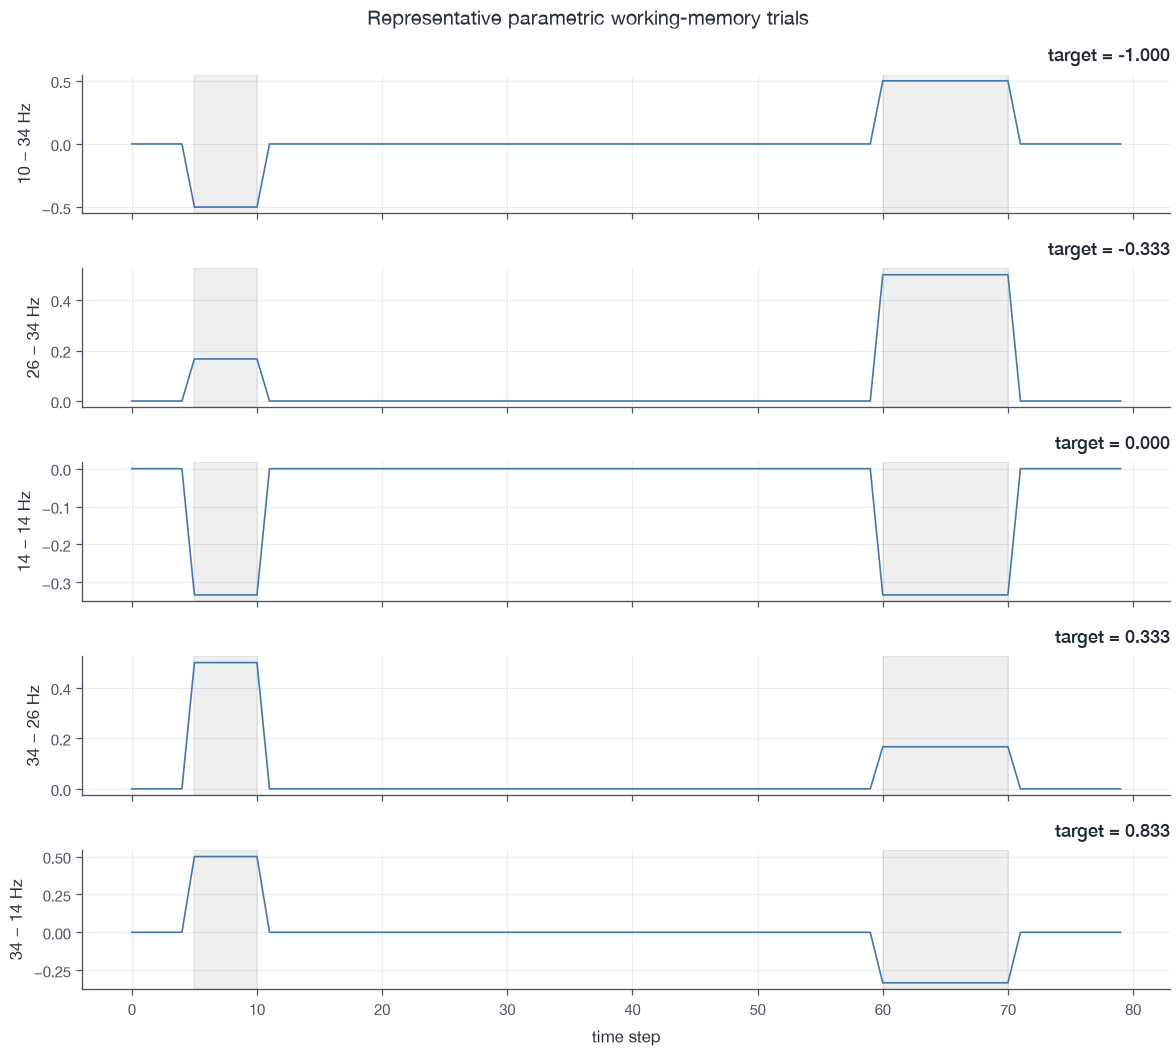

In [4]:
def plot_parametric_working_memory_trials(
    inputs,
    targets,
    frequencies,
    *,
    num_trials=5,
):
    num_plotted = min(num_trials, len(inputs))
    sorted_trials = np.argsort(targets)
    positions = np.linspace(0, len(sorted_trials) - 1, num_plotted, dtype=int)
    selected_trials = sorted_trials[positions]

    time_steps = np.arange(inputs.shape[1])
    fig, axes = plt.subplots(
        num_plotted,
        1,
        figsize=(10, 1.8 * num_plotted),
        sharex=True,
        squeeze=False,
    )
    axes = axes.ravel()

    for trial, ax in zip(selected_trials, axes):
        ax.plot(time_steps, inputs[trial], lw=1)
        ax.axvspan(*FIRST_STIMULUS_WINDOW, color="gray", alpha=0.12)
        ax.axvspan(*SECOND_STIMULUS_WINDOW, color="gray", alpha=0.12)
        f_1, f_2 = frequencies[trial]
        ax.set_ylabel(f"{f_1:g} − {f_2:g} Hz")
        ax.set_title(f"target = {targets[trial]:.3f}", loc="right")

    axes[-1].set_xlabel("time step")
    fig.suptitle("Representative parametric working-memory trials")
    fig.tight_layout()
    return fig, axes


train_inputs, train_targets, train_frequencies = generate_parametric_working_memory_trials(
    NUM_TRAIN_TRIALS,
    TRIAL_LENGTH,
    rng,
)
test_inputs, test_targets, test_frequencies = generate_parametric_working_memory_trials(
    NUM_TEST_TRIALS,
    TRIAL_LENGTH,
    rng,
)

plot_parametric_working_memory_trials(
    train_inputs,
    train_targets,
    train_frequencies,
)
plt.show()

## 3. Initialize a rank-two RNN

Extend the current low-rank model from rank one to arbitrary rank, then initialize this experiment with `NUM_UNITS = 128` and `RANK = 2`. Keep the notebook focused on experiment orchestration; reusable model code should live in the package.

In [5]:
model = LowRankRNN(NUM_UNITS, rank=2)
model

LowRankRNN()

## 4. Train

Minimize mean squared error between the target and the network output over the final `DECISION_STEPS = 5` time steps. The project brief gives a target loss below `5e-3`.

Epoch 100: loss=0.115290
Epoch 200: loss=0.115002
Epoch 300: loss=0.114905
Epoch 400: loss=0.004609
Epoch 500: loss=0.000831
Epoch 600: loss=0.000548
Epoch 700: loss=0.000365
Epoch 800: loss=0.000247
Epoch 900: loss=0.000197
Epoch 1000: loss=0.000172
Final training loss: 0.000172


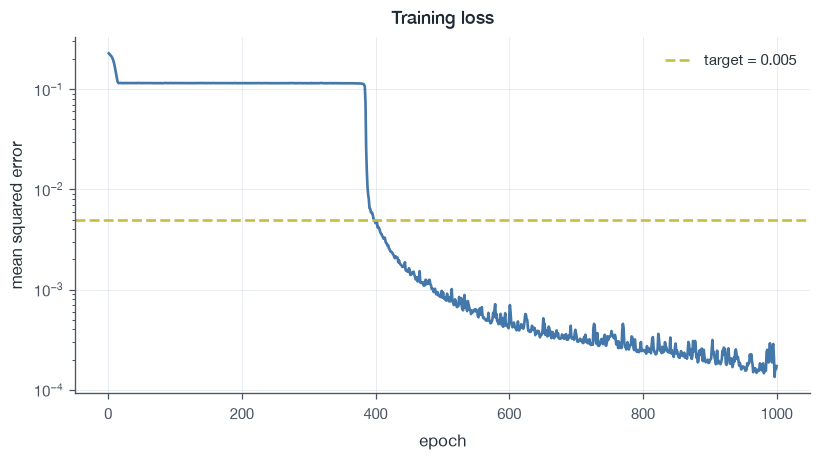

In [6]:
train_input_tensor = torch.as_tensor(train_inputs, dtype=torch.float32)
train_target_tensor = torch.as_tensor(train_targets, dtype=torch.float32)

losses = train_model(
    model,
    train_input_tensor,
    train_target_tensor,
    decision_steps=DECISION_STEPS,
    log_every=100,
)
print(f"Final training loss: {losses[-1]:.6f}")

epochs = np.arange(1, len(losses) + 1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epochs, losses)
ax.axhline(TARGET_LOSS, color="C3", ls="--", label=f"target = {TARGET_LOSS:g}")
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("mean squared error")
ax.set_title("Training loss")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Evaluate

Evaluate the trained network on fresh trials. Inspect held-out decision-window error and plot representative outputs alongside their continuous targets.

Test MSE over the final 5 time steps: 0.000250


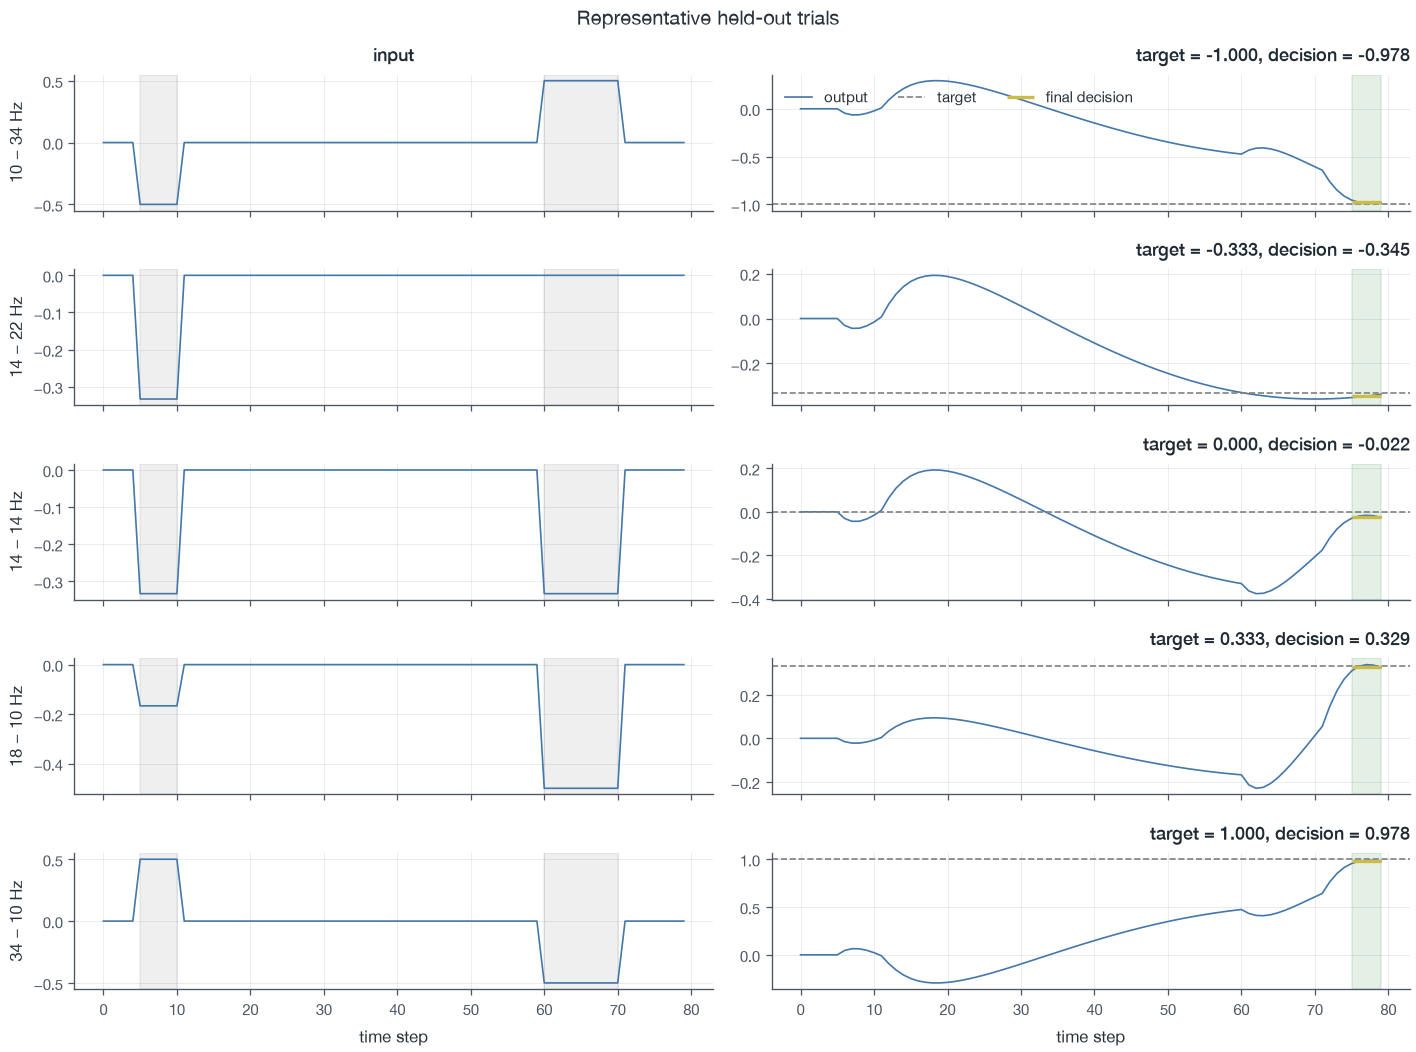

In [7]:
test_input_tensor = torch.as_tensor(test_inputs, dtype=torch.float32)
test_target_tensor = torch.as_tensor(test_targets, dtype=torch.float32)

model.eval()
with torch.no_grad():
    test_outputs, test_states = model(test_input_tensor)
    test_loss = decision_loss(
        test_outputs,
        test_target_tensor,
        decision_steps=DECISION_STEPS,
    )

print(f"Test MSE over the final {DECISION_STEPS} time steps: {test_loss.item():.6f}")

num_examples = 5
sorted_trials = np.argsort(test_targets)
positions = np.linspace(0, len(sorted_trials) - 1, num_examples, dtype=int)
example_trials = sorted_trials[positions]
decision_start = TRIAL_LENGTH - DECISION_STEPS

fig, axes = plt.subplots(
    num_examples,
    2,
    figsize=(12, 1.8 * num_examples),
    sharex=True,
    squeeze=False,
)
for trial, (input_axis, output_axis) in zip(example_trials, axes):
    output = test_outputs[trial].cpu().numpy()
    target = test_targets[trial]
    decision = output[-DECISION_STEPS:].mean()
    f_1, f_2 = test_frequencies[trial]

    input_axis.plot(test_inputs[trial], lw=1)
    input_axis.axvspan(*FIRST_STIMULUS_WINDOW, color="gray", alpha=0.12)
    input_axis.axvspan(*SECOND_STIMULUS_WINDOW, color="gray", alpha=0.12)
    input_axis.set_ylabel(f"{f_1:g} − {f_2:g} Hz")

    output_axis.plot(output, lw=1, label="output")
    output_axis.axhline(target, color="gray", ls="--", lw=1, label="target")
    output_axis.hlines(
        decision,
        decision_start,
        TRIAL_LENGTH - 1,
        color="C3",
        lw=2,
        label="final decision",
    )
    output_axis.axvspan(decision_start, TRIAL_LENGTH - 1, color="C2", alpha=0.12)
    output_axis.set_title(f"target = {target:.3f}, decision = {decision:.3f}", loc="right")

axes[0, 0].set_title("input")
axes[0, 1].legend(loc="upper left", ncols=3)
axes[-1, 0].set_xlabel("time step")
axes[-1, 1].set_xlabel("time step")
fig.suptitle("Representative held-out trials")
fig.tight_layout()
plt.show()

## 6. Analyze connectivity

Visualize the trained loading vectors and their covariance structure. Compare the learned patterns with Figure 3b of Dubreuil et al. and use them to reason about why the task requires rank two.

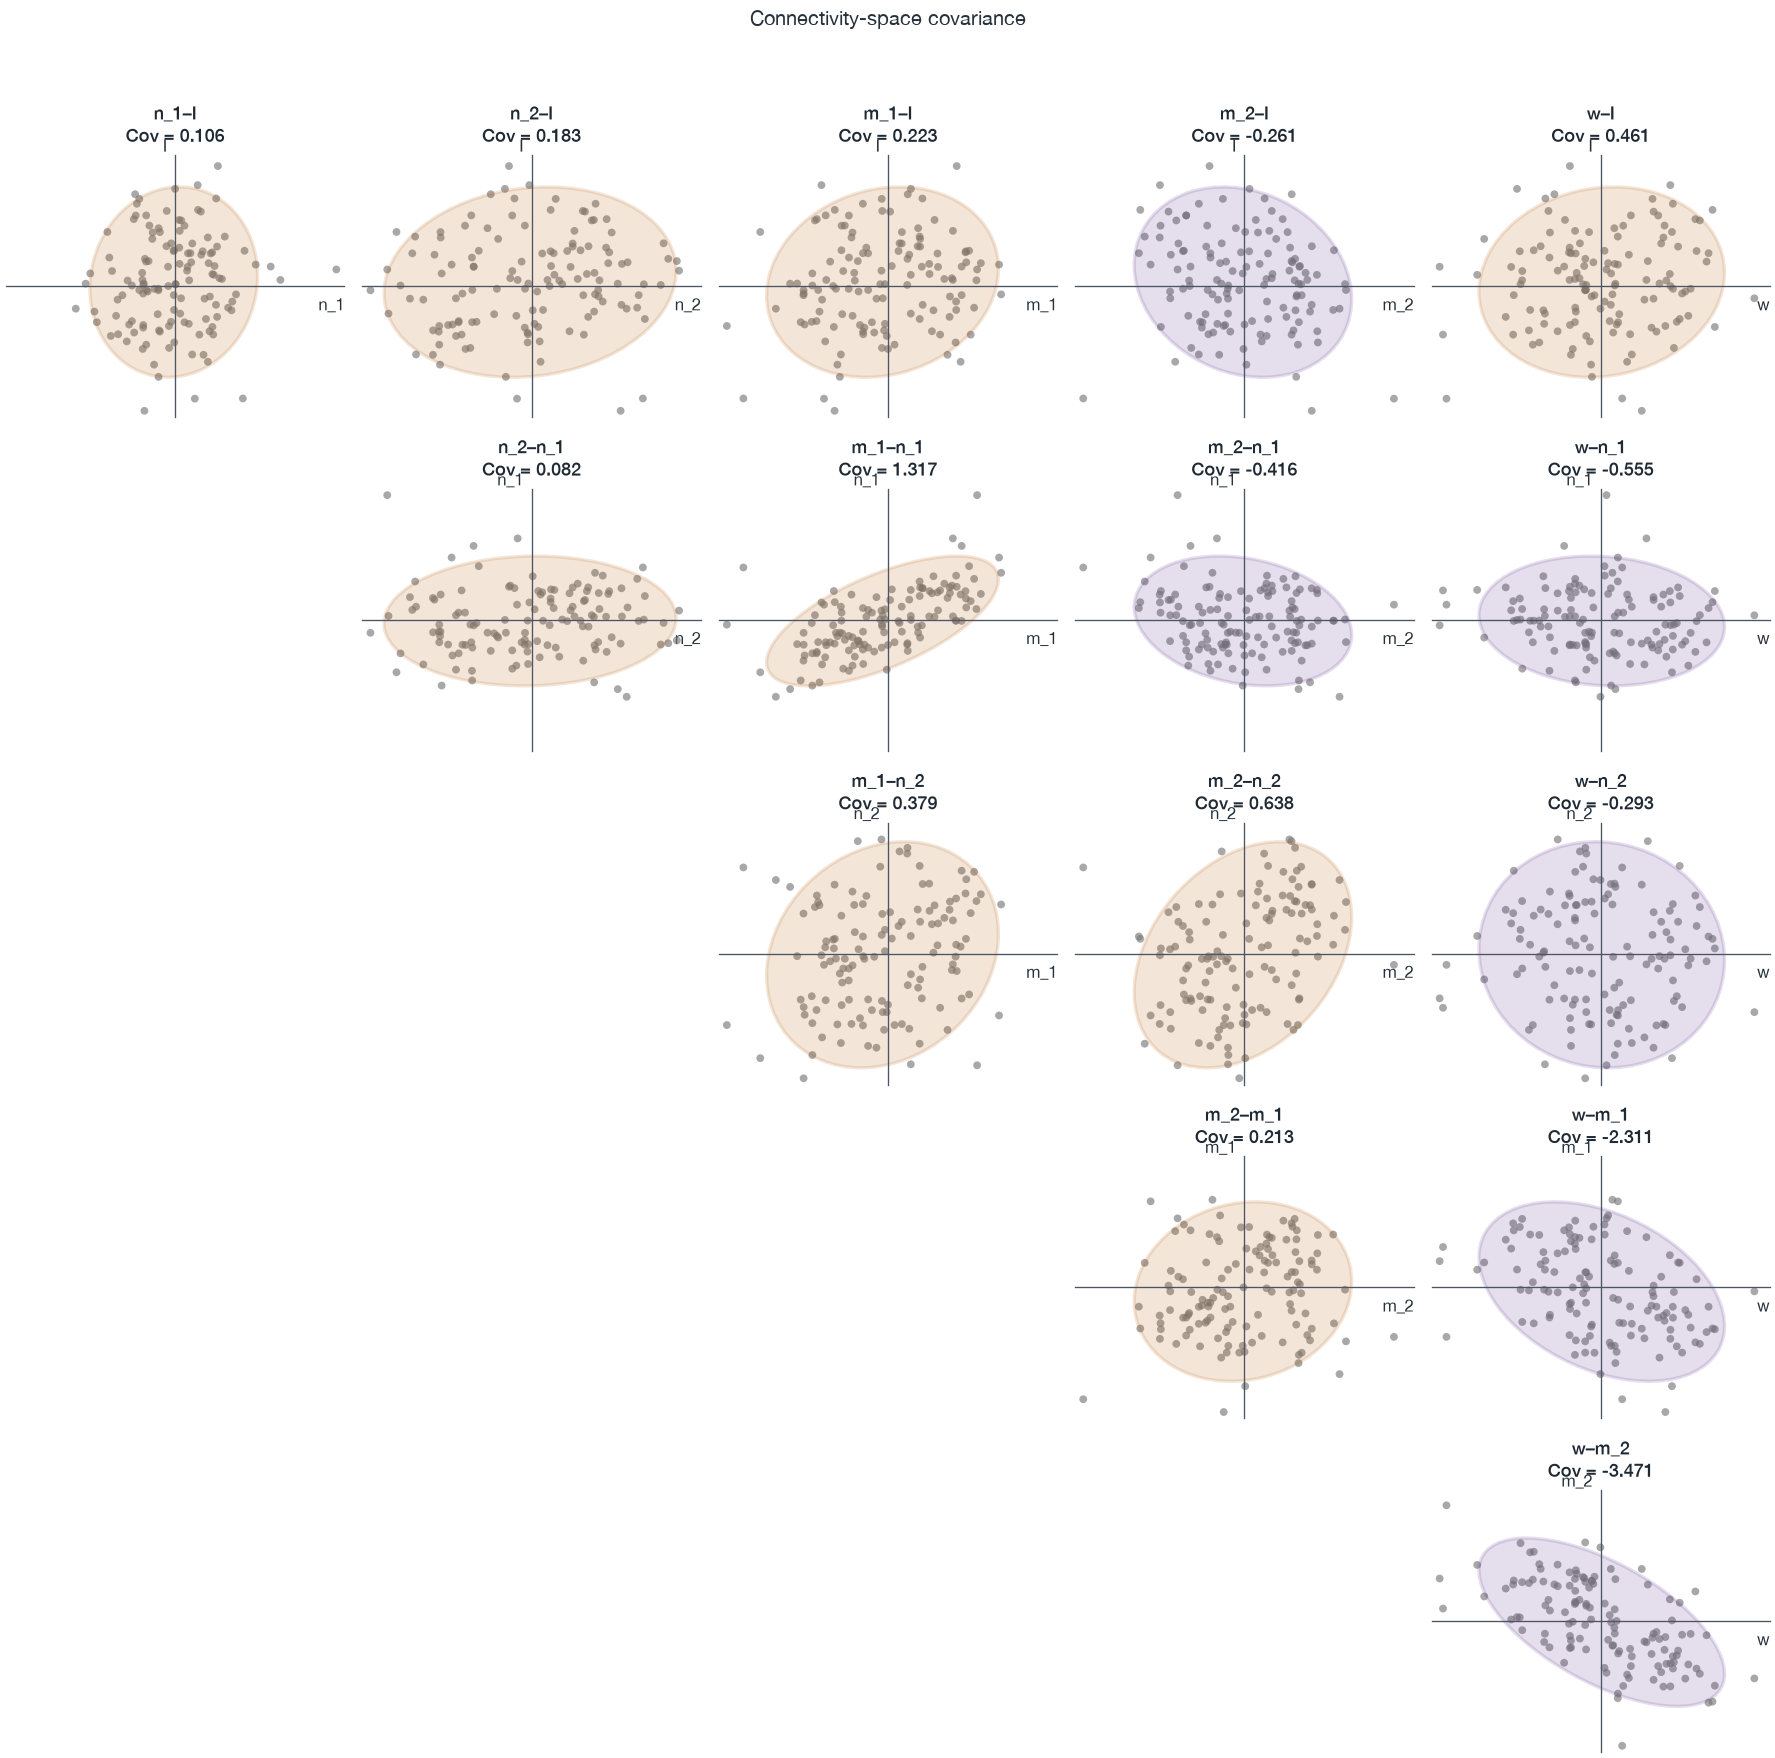

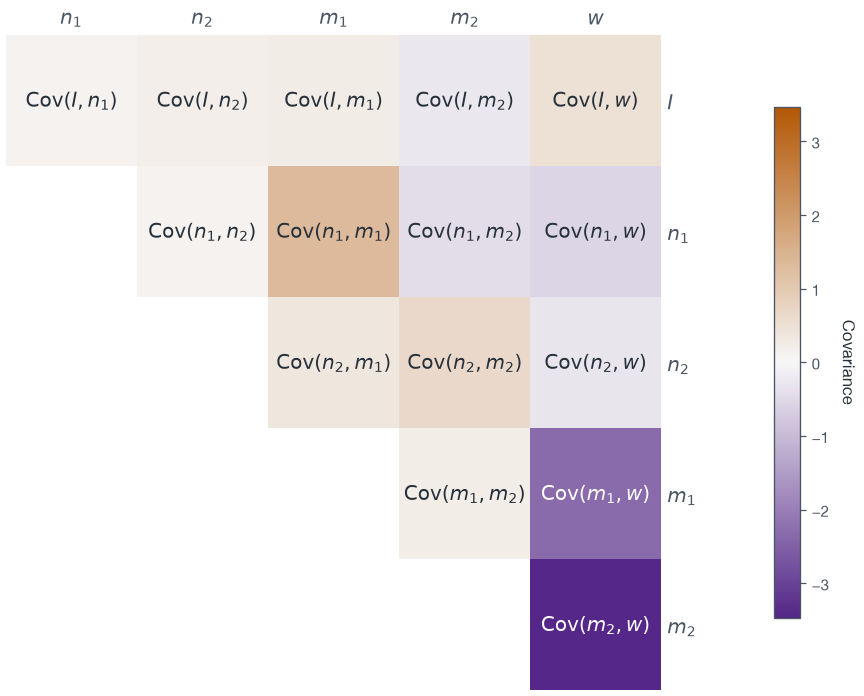

In [8]:
vectors = connectivity_vectors(model)
fig, axes = plot_connectivity_pairs(
    vectors,
    row_names=("I", "n_1", "n_2", "m_1", "m_2"),
    column_names=("n_1", "n_2", "m_1", "m_2", "w"),
)
plt.show()

names, covariance = connectivity_covariance(vectors)
fig, ax = plot_connectivity_covariance(names, covariance)
plt.show()

## 7. Project latent dynamics

Plot each input next to the corresponding hidden-state trajectory projected onto an orthonormal basis for $\operatorname{span}(m_1, m_2, I)$. Matching colors connect each stimulus pair across the two views.

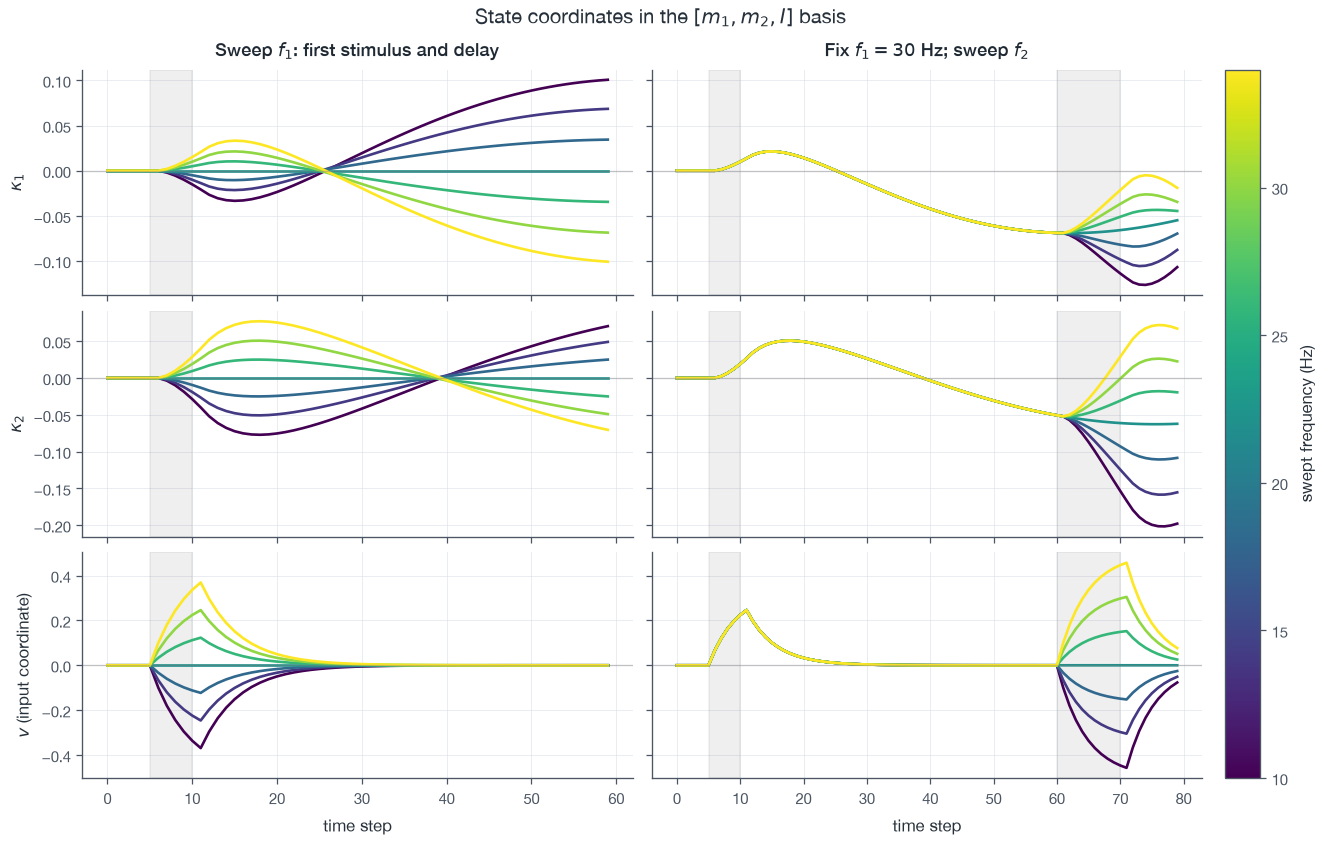

In [9]:
# x(t) = m_1 kappa_1(t) + m_2 kappa_2(t) + I v(t)
basis = torch.column_stack((model.m.detach(), model.I.detach()))
basis_inverse = torch.linalg.pinv(basis)


def state_coordinates_for_sweep(f_1_values, f_2_values):
    frequencies = np.column_stack((f_1_values, f_2_values))
    amplitudes = (
        frequencies - (MAX_FREQUENCY + MIN_FREQUENCY) / 2
    ) / (MAX_FREQUENCY - MIN_FREQUENCY)

    inputs = np.zeros((len(frequencies), TRIAL_LENGTH), dtype=np.float32)
    for values, (start, end) in zip(
        amplitudes.T, (FIRST_STIMULUS_WINDOW, SECOND_STIMULUS_WINDOW)
    ):
        inputs[:, start : end + 1] = values[:, None]

    with torch.no_grad():
        _, states = model(torch.as_tensor(inputs))

    return (states @ basis_inverse.T).cpu().numpy()


neutral_frequency = (MIN_FREQUENCY + MAX_FREQUENCY) / 2
f_1_coordinates = state_coordinates_for_sweep(
    FREQUENCIES, np.full_like(FREQUENCIES, neutral_frequency)
)
f_2_coordinates = state_coordinates_for_sweep(
    np.full_like(FREQUENCIES, 30.0), FREQUENCIES
)

time_steps = np.arange(TRIAL_LENGTH)
color_norm = plt.Normalize(MIN_FREQUENCY, MAX_FREQUENCY)
color_map = plt.get_cmap("viridis")
fig, axes = plt.subplots(
    3, 2, figsize=(11, 7), sharex="col", sharey="row", constrained_layout=True
)

panels = (
    (f_1_coordinates, SECOND_STIMULUS_WINDOW[0], (FIRST_STIMULUS_WINDOW,)),
    (
        f_2_coordinates,
        TRIAL_LENGTH,
        (FIRST_STIMULUS_WINDOW, SECOND_STIMULUS_WINDOW),
    ),
)
for column, (coordinates, stop, windows) in enumerate(panels):
    for trial, frequency in enumerate(FREQUENCIES):
        color = color_map(color_norm(frequency))
        for row in range(3):
            axes[row, column].plot(
                time_steps[:stop], coordinates[trial, :stop, row], color=color
            )
    for axis in axes[:, column]:
        axis.axhline(0, color="gray", lw=0.8, alpha=0.4)
        for start, end in windows:
            axis.axvspan(start, end, color="gray", alpha=0.12)

axes[0, 0].set_title(r"Sweep $f_1$: first stimulus and delay")
axes[0, 1].set_title(r"Fix $f_1=30$ Hz; sweep $f_2$")
for axis, label in zip(
    axes[:, 0], (r"$\kappa_1$", r"$\kappa_2$", r"$v$ (input coordinate)")
):
    axis.set_ylabel(label)
for axis in axes[-1]:
    axis.set_xlabel("time step")

fig.colorbar(
    plt.cm.ScalarMappable(norm=color_norm, cmap=color_map),
    ax=axes,
    label="swept frequency (Hz)",
    pad=0.02,
)
fig.suptitle(r"State coordinates in the $[m_1, m_2, I]$ basis")
plt.show()

### Trajectories in the $[m_1, m_2, I]$ coordinate space

The rank-one network of `model.ipynb` had a two-dimensional state space, so its
population trajectories fit in the $m$-$I$ plane. Here the state is

$$
x(t) = m_1 \kappa_1(t) + m_2 \kappa_2(t) + I\, v(t),
$$

so the same picture needs all three coordinates. Running the full $7 \times 7$
frequency grid puts every point of the input space on one figure: the two
three-dimensional views color the same 49 trajectories by $f_1$ and by $f_2$, and
the last panel shows where each stimulus pair ends up in the latent plane at
decision time.

In [ ]:
# One trajectory per (f_1, f_2) pair, in the latent coordinates of section 7.
grid_f_1, grid_f_2 = (
    values.ravel() for values in np.meshgrid(FREQUENCIES, FREQUENCIES, indexing="ij")
)
grid_coordinates = state_coordinates_for_sweep(grid_f_1, grid_f_2)
delay_end = SECOND_STIMULUS_WINDOW[0] - 1
decision_coordinates = grid_coordinates[:, -DECISION_STEPS:].mean(axis=1)

frequency_norm = plt.Normalize(MIN_FREQUENCY, MAX_FREQUENCY)
fig = plt.figure(figsize=(15, 5.6))
grid = fig.add_gridspec(1, 3, width_ratios=(1.15, 1.15, 0.9), wspace=0.32)

views = (
    (grid_f_1, "viridis", r"Colored by the remembered $f_1$", r"$f_1$ (Hz)"),
    (grid_f_2, "plasma", r"Colored by the comparison $f_2$", r"$f_2$ (Hz)"),
)
for column, (values, cmap_name, title, bar_label) in enumerate(views):
    axis = fig.add_subplot(grid[column], projection="3d")
    color_map = plt.get_cmap(cmap_name)
    for trial, value in enumerate(values):
        trajectory = grid_coordinates[trial]
        color = color_map(frequency_norm(value))
        axis.plot(*trajectory.T, color=color, lw=0.8, alpha=0.7)
        axis.scatter(*trajectory[-1], color=color, marker="X", s=26, depthshade=False)

    # Nothing depends on f_2 yet at the end of the delay, so the 49 trials sit on
    # seven points: the manifold the first stimulus writes the memory onto.
    axis.plot(
        *grid_coordinates[:, delay_end].T,
        color="0.25",
        ls="--",
        lw=1.2,
        label="memory manifold (end of delay)",
    )
    axis.scatter(0, 0, 0, color="0.25", marker="o", s=30, depthshade=False, label="start")
    if column == 0:
        axis.legend(loc="upper left", fontsize=8, framealpha=0.9, bbox_to_anchor=(0, 0.94))

    axis.set(
        xlabel=r"$\kappa_1$ (along $m_1$)",
        ylabel=r"$\kappa_2$ (along $m_2$)",
        title=title,
    )
    axis.set_zlabel(r"$v$ (along $I$)", labelpad=-2)
    axis.tick_params(pad=0)
    axis.view_init(elev=22, azim=-62)
    fig.colorbar(
        plt.cm.ScalarMappable(norm=frequency_norm, cmap=color_map),
        ax=axis,
        label=bar_label,
        orientation="horizontal",
        location="bottom",
        shrink=0.55,
        pad=0.02,
    )

# The input space itself: one lattice node per stimulus pair at decision time.
lattice = decision_coordinates.reshape(len(FREQUENCIES), len(FREQUENCIES), 3)
target_norm = plt.Normalize(-1, 1)
target_cmap = plt.get_cmap("coolwarm")
axis = fig.add_subplot(grid[2])
for index in range(len(FREQUENCIES)):
    axis.plot(lattice[index, :, 0], lattice[index, :, 1], color="0.75", lw=0.8)
    axis.plot(lattice[:, index, 0], lattice[:, index, 1], color="0.75", lw=0.8)
axis.scatter(
    lattice[..., 0],
    lattice[..., 1],
    c=(grid_f_1 - grid_f_2).reshape(lattice.shape[:2]) / (MAX_FREQUENCY - MIN_FREQUENCY),
    cmap=target_cmap,
    norm=target_norm,
    s=42,
    edgecolor="white",
    linewidth=0.5,
    zorder=3,
)
axis.set(
    xlabel=r"$\kappa_1$",
    ylabel=r"$\kappa_2$",
    title=r"Decision-window state across the $7 \times 7$ grid",
)
axis.set_aspect("equal", adjustable="datalim")
fig.colorbar(
    plt.cm.ScalarMappable(norm=target_norm, cmap=target_cmap),
    ax=axis,
    label=r"target $(f_1 - f_2) / (f_{\max} - f_{\min})$",
    orientation="horizontal",
    location="bottom",
    shrink=0.7,
    pad=0.16,
)
fig.suptitle(
    r"Population trajectories in the $[m_1, m_2, I]$ coordinates, "
    r"$7 \times 7$ frequency grid (X: end of trial)"
)
plt.show()

## 8. Test the loading-space Gaussian approximation

Fit a six-dimensional Gaussian to the connectivity loadings, resample networks from it, and compare their connectivity statistics and task performance with the trained network.

In [10]:
# TODO: Fit, sample, and evaluate the six-dimensional loading Gaussian.

## 9. Build the two-dimensional equivalent circuit

Use the learned covariance parameters to simulate the effective dynamics for $\kappa_1$ and $\kappa_2$, then compare the reduced circuit with the full network on matched inputs.

In [11]:
# TODO: Simulate and evaluate the two-dimensional equivalent circuit.

## 10. A fixed delay and a randomized delay are solved differently

Sections 2-9 used one fixed delay: the second stimulus always arrived at step 60
and the readout was always due five steps from the end. The paper instead draws
the blank interval uniformly from 500-2000 ms, which is 25-100 steps at the
model's 20 ms time step. Nothing in the fixed version demands a *stable* memory,
because the network knows exactly when it will be asked.

Two cohorts of four seeds test what that changes.

- **randomized delay** - trained on `low_rank_rnn.data.variable_delay` through a
  curriculum of widening ranges (100-500, 500-1000, 500-1500, 500-2000 ms, 300
  epochs each), carrying one optimizer throughout. The curriculum is not the
  object of study; it is here because it makes the line-attractor solution
  reliable across seeds, which training on the full range from the start does
  not.
- **fixed delay** - the section 2 paradigm unchanged, 980 ms between the two
  stimuli, 1000 epochs of minibatch Adam.

Both are then probed the same way. Each network sees the full $7 \times 7$
frequency grid at every delay from 500 to 2000 ms, with the second stimulus and
the decision window moving together, so the only thing that varies is how long
the network has to wait. A network trained at one delay is asked to work at all
the others.

### What the run shows

Every randomized-delay network lands on a line attractor. Held-out error is
0.0017-0.0041 and essentially flat: the error at 2000 ms is within a factor of
1.4 of the error at 980 ms. The leading delay eigenvalue is $-0.013$ to $-0.001$
and its imaginary part is zero to numerical precision, so the memory neither
decays nor turns.

Three of the four fixed-delay networks solve their own task far better than that:
0.0002-0.0003 at 980 ms, roughly seven times below what the generalists reach at
that same delay. A specialist beats a generalist on its own interval. Move the
stimulus and it collapses - 0.23, 0.56, and 0.72 at 2000 ms, three orders of
magnitude worse. The fourth, seed 2029, never learns at all; 0.11 is what you
score by reporting $-f_2$ and forgetting $f_1$ entirely.

All four have complex eigenvalues, $|\mathrm{Im}\,\lambda| = 0.19$-$0.29$ in
units of $1/\tau$, with real parts within 0.03 of zero for the three that learn.
The latent state rotates through the delay with a period of 2400-3300 ms,
comparable to the delay itself, rather than settling. Section 11 shows what that
rotation is for.

One caveat. The two cohorts differ in more than the delay distribution: the
fixed-delay arm keeps the section 2 geometry and minibatch Adam, the randomized
arm uses the `variable_delay` geometry and full batch. Imposing a fixed delay on
the `variable_delay` geometry instead does *not* reproduce the rotation - it
mostly fails to train at all, and the one seed in four that succeeds uses an
expanding real mode rather than a rotation. Rotation is what this particular
paradigm reliably finds, not the only clock a fixed delay permits. The
generalization gap is the construction-independent part: every fixed-delay
network, in either geometry, degrades by two to three orders of magnitude away
from its trained delay, and every randomized-delay network stays flat.

In [12]:
# Two ways of building trials. Both take the blank delay as a free parameter, so
# either network can be run at a delay it never trained on.
STEP_MS = 20.0
COHORT_SEEDS = (2026, 2027, 2028, 2029)
STAGE_EPOCHS = 300
CURRICULUM_STAGES = (
    np.arange(5, 26),
    np.arange(25, 51),
    np.arange(25, 76),
    delay_task.DELAYS,
)

# The section 2 geometry, re-expressed with its delay pulled out as a parameter.
SECOND_STIMULUS_STEPS = SECOND_STIMULUS_WINDOW[1] - SECOND_STIMULUS_WINDOW[0] + 1
DECISION_GAP = TRIAL_LENGTH - DECISION_STEPS - (SECOND_STIMULUS_WINDOW[1] + 1)
FIXED_DELAY = SECOND_STIMULUS_WINDOW[0] - (FIRST_STIMULUS_WINDOW[1] + 1)
PROBE_DELAYS = np.unique(np.concatenate((delay_task.DELAYS[::5], [FIXED_DELAY])))
FIXED_DELAY_INDEX = int(np.searchsorted(PROBE_DELAYS, FIXED_DELAY))


class Paradigm(NamedTuple):
    """A trial builder whose blank delay is a free parameter.

    Trials always end on their decision window, so ``decision_loss`` scores them
    directly, and ``delay_onset`` says where the blank period starts.
    """

    name: str
    trials: Callable[[np.ndarray, int], tuple[torch.Tensor, torch.Tensor]]
    delay_onset: int
    trained_delay: int
    first_stimulus_steps: int
    second_stimulus_steps: int


def randomized_delay_trials(frequencies, delay):
    """``variable_delay`` trials at one delay, trimmed to end on the readout."""
    inputs, targets, _ = delay_task.make_trials(
        frequencies, np.full(len(frequencies), delay)
    )
    onset = delay_task.FIXATION_STEPS + delay_task.STIMULUS_STEPS
    stop = onset + delay + delay_task.STIMULUS_STEPS + DECISION_STEPS
    return inputs[:, :stop], targets


def fixed_delay_trials(frequencies, delay=FIXED_DELAY):
    """Section 2 trials with stimulus 2 free to move, dragging the readout."""
    amplitudes = delay_task.stimulus_amplitudes(frequencies)
    first_start, first_end = FIRST_STIMULUS_WINDOW
    second_start = first_end + 1 + delay
    length = second_start + SECOND_STIMULUS_STEPS + DECISION_GAP + DECISION_STEPS

    inputs = np.zeros((len(amplitudes), length), dtype=np.float32)
    inputs[:, first_start : first_end + 1] = amplitudes[:, 0, None]
    inputs[:, second_start : second_start + SECOND_STIMULUS_STEPS] = amplitudes[:, 1, None]
    targets = amplitudes[:, 0] - amplitudes[:, 1]
    return torch.as_tensor(inputs), torch.as_tensor(targets, dtype=torch.float32)


RANDOMIZED = Paradigm(
    "randomized delay",
    randomized_delay_trials,
    delay_task.FIXATION_STEPS + delay_task.STIMULUS_STEPS,
    delay_task.DELAYS.max(),
    delay_task.STIMULUS_STEPS,
    delay_task.STIMULUS_STEPS,
)
FIXED = Paradigm(
    "fixed delay",
    fixed_delay_trials,
    FIRST_STIMULUS_WINDOW[1] + 1,
    FIXED_DELAY,
    FIRST_STIMULUS_WINDOW[1] - FIRST_STIMULUS_WINDOW[0] + 1,
    SECOND_STIMULUS_STEPS,
)

In [13]:
# One analysis, applied to both paradigms.


@torch.no_grad()
def probe_across_delays(model, paradigm, delays=PROBE_DELAYS):
    """Decision-window error over the whole frequency grid at each delay."""
    errors = []
    for delay in delays:
        inputs, targets = paradigm.trials(delay_task.frequency_pair_grid(), delay)
        outputs, _ = model(inputs)
        errors.append(decision_loss(outputs, targets, decision_steps=DECISION_STEPS).item())
    return np.asarray(errors)


@torch.no_grad()
def coding_coefficients(model, paradigm, delay=None):
    """Regress latents and readout on the two stimulus amplitudes, step by step.

    Runs every ordered frequency pair at one delay and fits, at each time step,
    ``kappa_i(t) = a + B[0, t, i] u_1 + B[1, t, i] u_2``, and the same for the
    network output. The weights say how strongly each stimulus is represented at
    each moment, and along which latent direction.
    """
    delay = paradigm.trained_delay if delay is None else delay
    pairs = delay_task.frequency_pair_grid()
    inputs, _ = paradigm.trials(pairs, delay)
    outputs, states = model(inputs)
    latents = (states @ torch.linalg.pinv(model.m).T).cpu().numpy()

    design = np.column_stack((np.ones(len(pairs)), delay_task.stimulus_amplitudes(pairs)))
    weights = np.linalg.pinv(design)[1:]  # drop the intercept row

    return {
        "delay": delay,
        "delay_steps": slice(paradigm.delay_onset, paradigm.delay_onset + delay + 1),
        "decision_steps": slice(inputs.shape[1] - DECISION_STEPS, inputs.shape[1]),
        "latent_coding": np.einsum("vp,ptr->vtr", weights, latents),
        "readout_coding": weights @ outputs.cpu().numpy(),
    }


def coding_axis_angle(coding, variable=0):
    """Unwrapped direction of one stimulus's coding axis in the latent plane.

    A stationary memory holds this angle fixed; a rotating memory advances it at
    a constant rate, so its slope over the delay is the rotation frequency.
    """
    axis = coding["latent_coding"][variable]
    return np.unwrap(np.arctan2(axis[:, 1], axis[:, 0]))


def delay_rotation(coding, window=(25, 100)):
    """Degrees the f_1 coding axis turns between two points inside the delay.

    The window opens at the shortest task delay, past the transient in which the
    non-memory mode collapses, so this measures the steady turn of the memory
    rather than the initial swing.
    """
    angle = coding_axis_angle(coding)
    start = coding["delay_steps"].start
    return np.degrees(angle[start + window[1]] - angle[start + window[0]])


def stimulus_axis_separation(coding):
    """Angle between the f_1 and f_2 coding axes during the decision window.

    Near 0 or 180 degrees both stimuli load a single latent direction, and the
    difference has already been formed by the dynamics; in between, the readout
    is what combines two genuinely separate directions.
    """
    axes = coding["latent_coding"][:, coding["decision_steps"]].mean(axis=1)
    cosine = axes[0] @ axes[1] / np.linalg.norm(axes, axis=1).prod()
    return np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0)))


def decision_readout_weights(model, paradigm, delays=PROBE_DELAYS):
    """Readout sensitivity to f_1 and f_2 inside the decision window, per delay.

    The task is solved when these sit at ``(+1, -1)``: the network reports
    ``u_1 - u_2``. A memory that rotates reaches them only near one delay.
    """
    weights = [
        coding_coefficients(model, paradigm, delay)["readout_coding"][
            :, -DECISION_STEPS:
        ].mean(axis=1)
        for delay in delays
    ]
    return np.asarray(weights)


@torch.no_grad()
def latent_trajectories(model, paradigm, frequencies, delay=None):
    """Latent coordinates over a whole trial, one row per frequency pair."""
    delay = paradigm.trained_delay if delay is None else delay
    inputs, _ = paradigm.trials(frequencies, delay)
    _, states = model(inputs)
    return (states @ torch.linalg.pinv(model.m).T).cpu().numpy()


def stimulus_sweeps(model, paradigm, delay=None):
    """Latent responses to sweeping each stimulus while the other is held.

    Follows figure 3h of Dubreuil et al.: sweep f_1 against a neutral f_2, then
    hold f_1 at the top of the range and sweep f_2.
    """
    neutral = np.full_like(FREQUENCIES, FREQUENCIES.mean())
    top = np.full_like(FREQUENCIES, MAX_FREQUENCY)
    return tuple(
        latent_trajectories(model, paradigm, pairs, delay)
        for pairs in (
            np.column_stack((FREQUENCIES, neutral)),
            np.column_stack((top, FREQUENCIES)),
        )
    )


def stimulus_windows(paradigm, delay):
    """The two stimulus presentations, as ``(start, stop)`` pairs of steps."""
    second_start = paradigm.delay_onset + delay
    return (
        (paradigm.delay_onset - paradigm.first_stimulus_steps, paradigm.delay_onset),
        (second_start, second_start + paradigm.second_stimulus_steps),
    )


def memory_latents(model, paradigm, delay=None):
    """Latent coordinates over the delay, sweeping f_1 with f_2 held neutral."""
    delay = paradigm.trained_delay if delay is None else delay
    sweep, _ = stimulus_sweeps(model, paradigm, delay)
    return sweep[:, paradigm.delay_onset : paradigm.delay_onset + delay + 1]


def representative(cohort):
    """The seed in a cohort that fits its own trained delay best."""
    index = int(np.searchsorted(PROBE_DELAYS, cohort[0]["paradigm"].trained_delay))
    return min(cohort, key=lambda result: result["probe_mse"][index])


def diagnose(model, paradigm):
    """Everything sections 10-12 report about one trained network.

    ``coding`` runs the network at the delay it was trained for, ``long_coding``
    at the longest probe delay, letting the autonomous delay dynamics play out
    well past the point where either network expects to be read out.
    """
    latents = memory_latents(model, paradigm)
    coding = coding_coefficients(model, paradigm)
    long_coding = coding_coefficients(model, paradigm, PROBE_DELAYS.max())
    return {
        "paradigm": paradigm,
        "memory_latents": latents,
        "probe_mse": probe_across_delays(model, paradigm),
        "readout_weights": decision_readout_weights(model, paradigm),
        "eigenvalues": delay_eigenvalues(model, torch.as_tensor(latents[:, -1])),
        "coding": coding,
        "long_coding": long_coding,
        "rotation": delay_rotation(long_coding),
        "axis_separation": stimulus_axis_separation(coding),
        "overlap": (model.n.T @ model.m / model.n_units).detach().cpu().numpy(),
    }

In [14]:
def train_randomized(seed):
    """A curriculum of widening delay ranges, one optimizer throughout."""
    torch.manual_seed(seed)
    model = LowRankRNN(NUM_UNITS, rank=RANK)
    losses = train_variable_delay(
        model,
        CURRICULUM_STAGES,
        rng=np.random.default_rng(seed),
        epochs_per_stage=STAGE_EPOCHS,
    )
    return model, np.asarray(losses)


def train_fixed(seed):
    """The section 4 recipe, unchanged: one delay, minibatch Adam."""
    rng = np.random.default_rng(seed)
    torch.manual_seed(seed)
    model = LowRankRNN(NUM_UNITS, rank=RANK)
    inputs, targets = fixed_delay_trials(
        rng.choice(FREQUENCIES, size=(NUM_TRAIN_TRIALS, 2))
    )
    losses = train_model(
        model, inputs, targets, decision_steps=DECISION_STEPS, log_every=None
    )
    model.eval()
    return model, np.asarray(losses)


def train_cohort(train_one, paradigm):
    """One network per seed, each paired with its delay diagnostics."""
    cohort = []
    for seed in COHORT_SEEDS:
        model, losses = train_one(seed)
        cohort.append(
            {"seed": seed, "model": model, "losses": losses, **diagnose(model, paradigm)}
        )
    return cohort


def describe(cohort):
    """One line per network, contrasting 980 ms with the longest delay."""
    for result in cohort:
        leading = result["eigenvalues"][:, 0].mean()
        print(
            f"{result['paradigm'].name:<17} seed {result['seed']}:  "
            f"train {result['losses'][-1]:.4f}   "
            f"MSE(980 ms) {result['probe_mse'][FIXED_DELAY_INDEX]:.4f}   "
            f"MSE(2000 ms) {result['probe_mse'][-1]:.4f}   "
            f"lambda_1 {leading.real:+.3f}{leading.imag:+.3f}i   "
            f"axis turn {result['rotation']:+4.0f} deg   "
            f"f1/f2 axes {result['axis_separation']:3.0f} deg"
        )


randomized_cohort = train_cohort(train_randomized, RANDOMIZED)
fixed_cohort = train_cohort(train_fixed, FIXED)
COHORTS = (
    (randomized_cohort, RANDOMIZED.name, COLORS["blue"]),
    (fixed_cohort, FIXED.name, COLORS["purple"]),
)

describe(randomized_cohort)
describe(fixed_cohort)

randomized delay  seed 2026:  train 0.0028   MSE(980 ms) 0.0028   MSE(2000 ms) 0.0029   lambda_1 -0.001+0.000i   axis turn   +1 deg   f1/f2 axes 124 deg
randomized delay  seed 2027:  train 0.0016   MSE(980 ms) 0.0018   MSE(2000 ms) 0.0022   lambda_1 -0.006+0.000i   axis turn   -2 deg   f1/f2 axes 101 deg
randomized delay  seed 2028:  train 0.0020   MSE(980 ms) 0.0018   MSE(2000 ms) 0.0023   lambda_1 -0.008+0.000i   axis turn   -2 deg   f1/f2 axes 120 deg
randomized delay  seed 2029:  train 0.0037   MSE(980 ms) 0.0030   MSE(2000 ms) 0.0041   lambda_1 -0.013+0.000i   axis turn   +1 deg   f1/f2 axes 119 deg
fixed delay       seed 2026:  train 0.0002   MSE(980 ms) 0.0003   MSE(2000 ms) 0.2284   lambda_1 -0.029+0.189i   axis turn +142 deg   f1/f2 axes 166 deg
fixed delay       seed 2027:  train 0.0002   MSE(980 ms) 0.0002   MSE(2000 ms) 0.7176   lambda_1 +0.023+0.259i   axis turn -267 deg   f1/f2 axes 177 deg
fixed delay       seed 2028:  train 0.0002   MSE(980 ms) 0.0003   MSE(2000 ms) 0.5

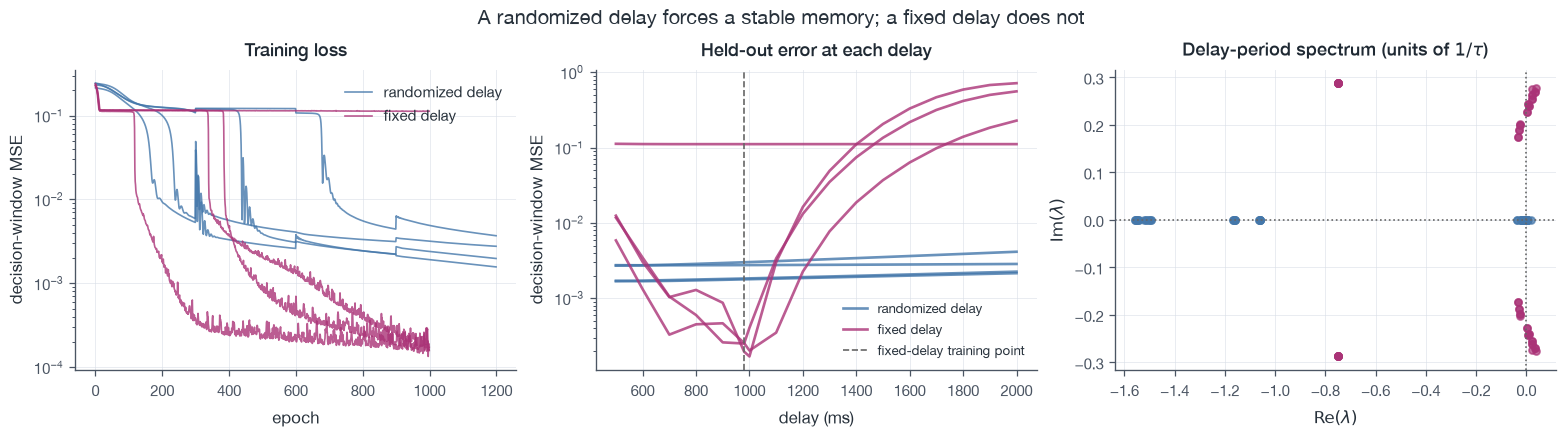

In [15]:
# Learning, generalization across delays, and the delay-period spectrum.
PROBE_MS = STEP_MS * PROBE_DELAYS
FIXED_DELAY_MS = STEP_MS * FIXED_DELAY

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), constrained_layout=True)
for cohort, label, color in COHORTS:
    for index, result in enumerate(cohort):
        legend = label if index == 0 else None
        axes[0].plot(result["losses"], color=color, lw=1, alpha=0.8, label=legend)
        axes[1].plot(PROBE_MS, result["probe_mse"], color=color, alpha=0.8, label=legend)
        eigenvalues = result["eigenvalues"]
        axes[2].scatter(
            eigenvalues.real, eigenvalues.imag, color=color, s=18, alpha=0.7, label=legend
        )

axes[0].set(
    yscale="log", xlabel="epoch", ylabel="decision-window MSE", title="Training loss"
)
axes[0].legend(loc="upper right")

axes[1].axvline(FIXED_DELAY_MS, color="0.4", ls="--", lw=1, label="fixed-delay training point")
axes[1].set(
    yscale="log",
    xlabel="delay (ms)",
    ylabel="decision-window MSE",
    title="Held-out error at each delay",
)
axes[1].legend(loc="lower right", fontsize=8)

axes[2].axhline(0, color="0.4", ls=":", lw=1)
axes[2].axvline(0, color="0.4", ls=":", lw=1)
axes[2].set(
    xlabel=r"$\mathrm{Re}(\lambda)$",
    ylabel=r"$\mathrm{Im}(\lambda)$",
    title=r"Delay-period spectrum (units of $1/\tau$)",
)

fig.suptitle("A randomized delay forces a stable memory; a fixed delay does not")
plt.show()

## 11. What the latent coordinates do during the delay

The network's whole state lives in $\operatorname{span}(m_1, m_2, I)$, and
during the blank delay the input term is off, so the memory is entirely the two
latent coordinates $\kappa = m^{+} x$.

The direct way to see what they carry is figure 3h of Dubreuil et al.: sweep one
stimulus while holding the other, and watch both latents. The first figure below
does that for one network from each cohort, both at a 980 ms delay so the panels
line up.

To turn that picture into numbers, run the full $7 \times 7$ frequency grid at
one delay and regress, at every time step, both the latents and the output on
the two stimulus amplitudes:

$$
\kappa_i(t) = a_i(t) + B_{1i}(t)\, u_1 + B_{2i}(t)\, u_2,
\qquad
z(t) = a(t) + c_1(t)\, u_1 + c_2(t)\, u_2 .
$$

Row $B_v(t) \in \mathbb{R}^2$ is the direction in the latent plane along which
stimulus $v$ is written at time $t$, and $c(t)$ is what the readout makes of it.
The task is solved exactly when $c = (+1, -1)$ inside the decision window: the
network reports $u_1 - u_2$.

Three quantities come out of this.

1. **Which latent carries what**, from $B(t)$ over the trial.
2. **How the $f_1$ code moves**, from the angle of $B_1(t)$ in the latent plane,
   measured against its value at delay onset. A stationary memory holds it
   fixed; a rotating one advances it at a constant rate.
3. **Whether the answer arrives on time**, from $c$ inside the decision window,
   as a function of delay.

Only the third is basis-free. The latent frame is fixed by the learned $m$, so
an angle in that plane is only meaningful relative to another angle in the same
network - which is all points 1 and 2 use. The readout weights $c$ are
properties of the network's output and carry no basis ambiguity at all.

### What the run shows

Sweeping $f_1$ in the randomized-delay network separates the traces immediately,
and the separation lands almost entirely in $\kappa_2$: $\kappa_1$ shows a
transient ordered by $f_1$ and then relaxes back to zero, while $\kappa_2$ fans
out and holds flat for the rest of the delay. Sweeping $f_2$ leaves both latents
on a single shared trace through the delay - $f_1$ is held, so there is nothing
to separate - until the second stimulus arrives and pulls them apart again, now
mostly along $\kappa_1$. One latent holds the remembered value, the other takes
the fresh one.

The fixed-delay network never settles. Each fan opens, collapses to a crossing
point, and reopens with the ordering reversed - near 800 ms in $\kappa_1$ and
near 400 ms in $\kappa_2$, at different times in the two latents as a rotation
requires - and the held-$f_1$ trace in the $f_2$ columns arcs through the delay
instead of flattening. The stimulus is still represented the whole time; the
plane it is written in keeps turning.

The regression puts numbers on both.

**Randomized delay.** Both latents move while the first stimulus is on, and
within about 400 ms of delay onset the $f_1$ code settles onto a direction it
then holds for the rest of the delay: that axis turns between $-2^\circ$ and
$+1^\circ$ over the whole 500-2000 ms window. The second stimulus arrives on a
*different* direction, 101-124 degrees away from the stored one. The readout does
the rest, and it does it at every delay - $c_1$ stays within 0.04 of $+1$ and
$c_2$ within 0.03 of $-1$ across the entire range.

That is the mechanism in one sentence: one latent direction holds the remembered
value, a second carries the fresh one, and $w$ takes the difference. Because the
two directions sit roughly $110^\circ$ apart rather than parallel, neither is a
rescaling of the other, which is why the task needs rank two.

**Fixed delay.** The $f_1$ code never stops turning - 142 to 267 degrees between
500 and 2000 ms into the delay, one revolution per 2400-3300 ms, matching
$|\mathrm{Im}\,\lambda|$ from section 10. By the decision window the two coding
axes are 166-177 degrees apart, nearly antiparallel. The rotation has carried the
stored $f_1$ around until it lands, with the opposite sign, on the same latent
direction the fresh $f_2$ arrives on, so here the difference is formed by the
dynamics rather than by the readout.

That works at exactly one phase. $c_1$ traces a cosine in the delay: about $+0.7$
at 500 ms, above $+1$ near 800 ms, back through $+1$ at the trained delay, through
zero near 1400 ms, and down to $-1.5$ at 2000 ms. Worst-case $|c_1 - 1|$ over the
delay range is 1.00-2.53, against 0.02-0.04 for the randomized cohort. Meanwhile
$c_2$ sits at $-1$ throughout, because $f_2$ needs no memory. Only the remembered
variable's readout weight oscillates, and the answer is right only when the
readout happens to be taken at the right phase.

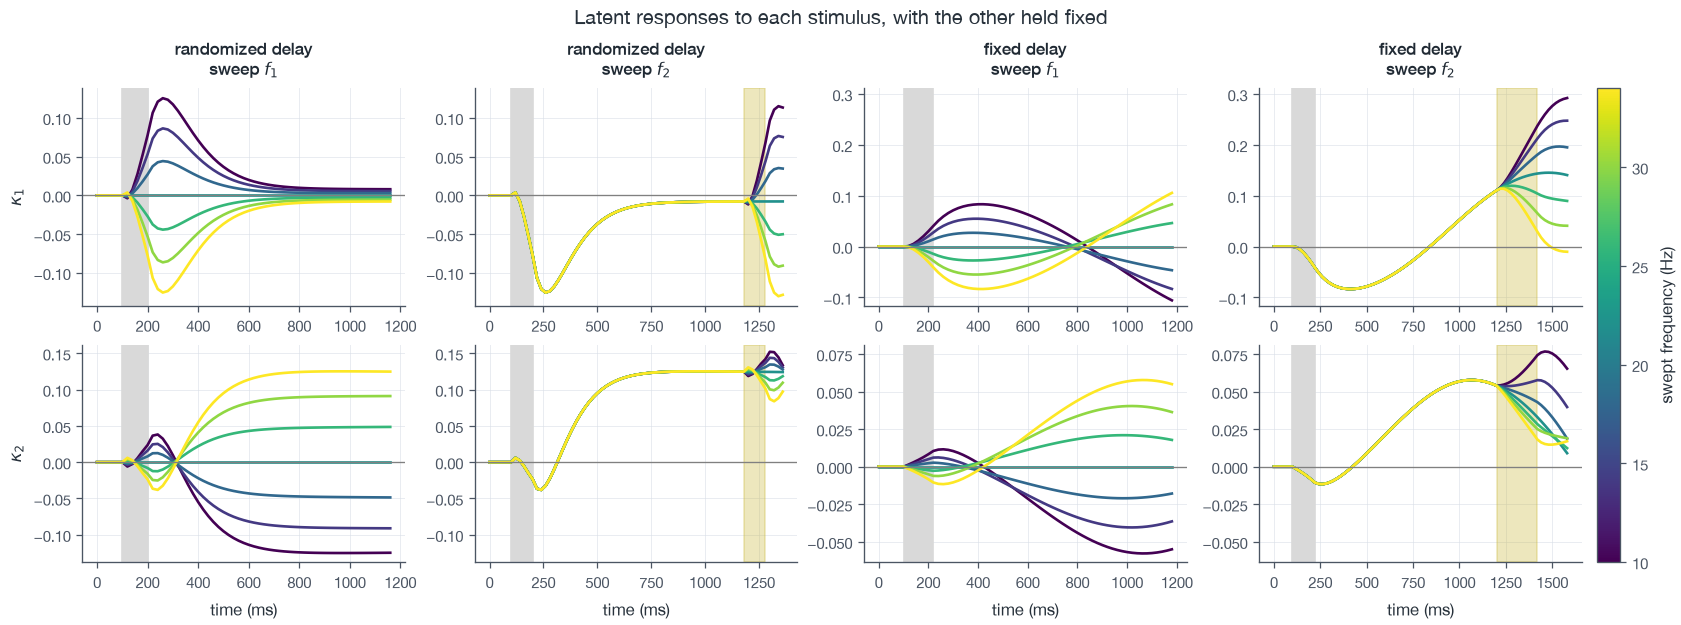

In [16]:
# Sweep one stimulus, hold the other, and watch both latents, as in figure 3h of
# Dubreuil et al. Both networks are shown at 980 ms so the panels line up.
FREQUENCY_NORM = plt.Normalize(MIN_FREQUENCY, MAX_FREQUENCY)
FREQUENCY_CMAP = plt.get_cmap("viridis")

fig, axes = plt.subplots(RANK, 4, figsize=(14, 5.2), constrained_layout=True)
for block, (cohort, label, _) in enumerate(COHORTS):
    example = representative(cohort)
    paradigm = example["paradigm"]
    sweeps = stimulus_sweeps(example["model"], paradigm, FIXED_DELAY)
    first, second = stimulus_windows(paradigm, FIXED_DELAY)

    for swept, trajectories in enumerate(sweeps):
        column = 2 * block + swept
        # Nothing has happened yet in the f_1 sweep, so cut it at stimulus 2.
        stop = second[0] if swept == 0 else trajectories.shape[1]
        for latent in range(RANK):
            axis = axes[latent, column]
            for trial, frequency in enumerate(FREQUENCIES):
                axis.plot(
                    STEP_MS * np.arange(stop),
                    trajectories[trial, :stop, latent],
                    color=FREQUENCY_CMAP(FREQUENCY_NORM(frequency)),
                )
            axis.axhline(0, color="0.5", lw=0.8)
            axis.axvspan(STEP_MS * first[0], STEP_MS * first[1], color="0.85")
            if stop > second[0]:
                axis.axvspan(
                    STEP_MS * second[0], STEP_MS * second[1], color=COLORS["gold"], alpha=0.35
                )
        axes[0, column].set_title(f"{label}\n" + rf"sweep $f_{swept + 1}$", fontsize=10)
        axes[-1, column].set_xlabel("time (ms)")

# Latent scale is arbitrary, so match it within a network but not across them.
for row in axes:
    for block in range(len(COHORTS)):
        pair = row[2 * block : 2 * block + 2]
        limits = [axis.get_ylim() for axis in pair]
        for axis in pair:
            axis.set_ylim(min(low for low, _ in limits), max(high for _, high in limits))
for latent in range(RANK):
    axes[latent, 0].set_ylabel(rf"$\kappa_{latent + 1}$")

fig.colorbar(
    plt.cm.ScalarMappable(norm=FREQUENCY_NORM, cmap=FREQUENCY_CMAP),
    ax=axes,
    label="swept frequency (Hz)",
    pad=0.01,
)
fig.suptitle("Latent responses to each stimulus, with the other held fixed")
plt.show()

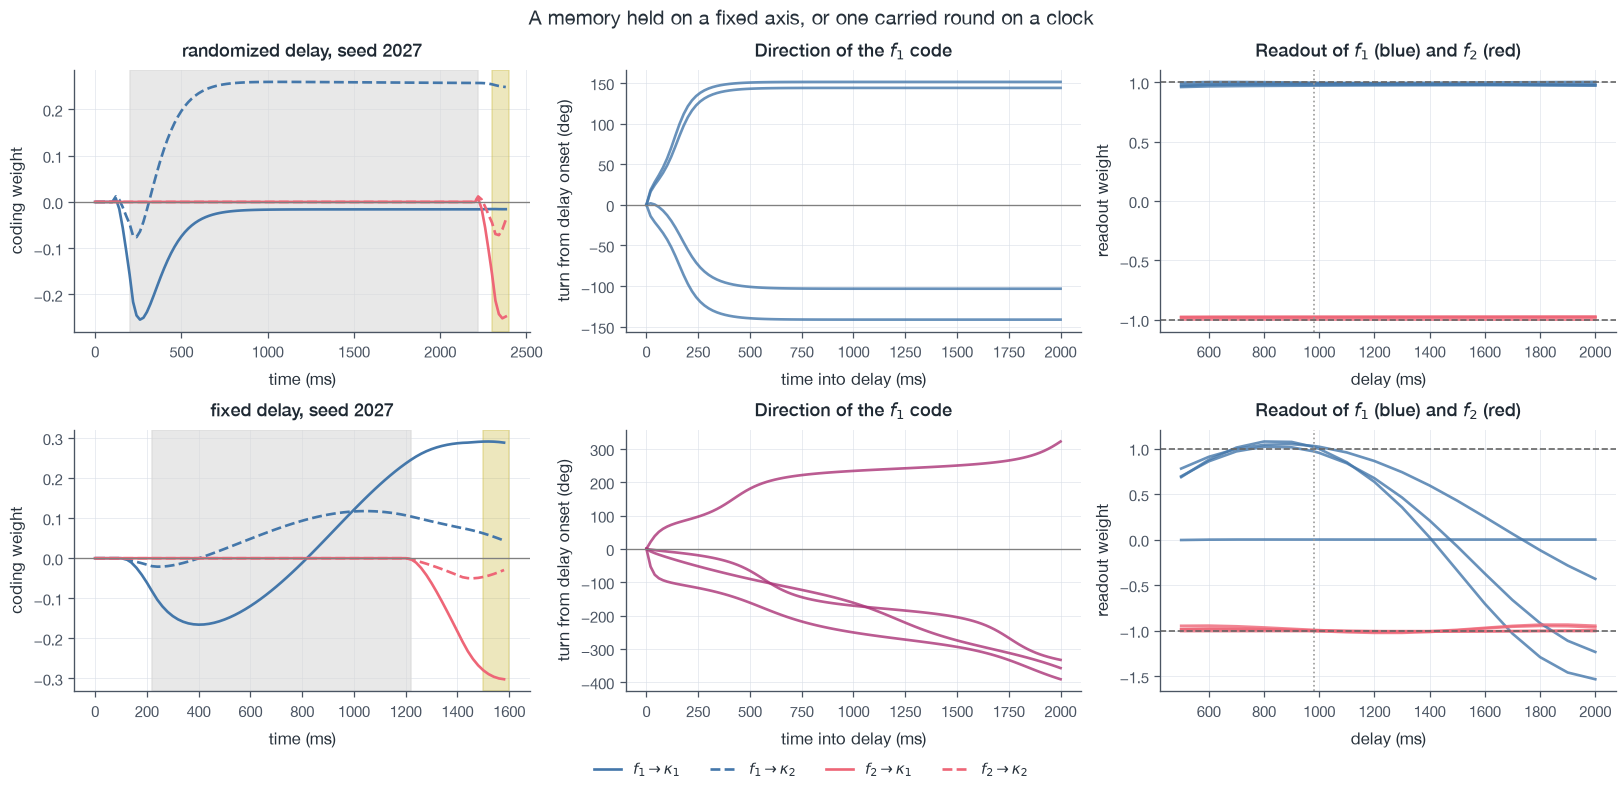

randomized delay  f_1 axis turn over 500-2000 ms: -2 to +1 deg   worst |c_1 - 1| across delays: 0.02 to 0.04
fixed delay       f_1 axis turn over 500-2000 ms: -267 to +142 deg   worst |c_1 - 1| across delays: 1.00 to 2.53


In [17]:
# Row per cohort: the coding time course for one seed, then all four seeds.
VARIABLE_COLORS = (COLORS["blue"], COLORS["red"])

fig, axes = plt.subplots(2, 3, figsize=(13.5, 6.6), constrained_layout=True)
for row, (cohort, label, color) in zip(axes, COHORTS):
    example = representative(cohort)
    coding = example["coding"]
    delay, decision = coding["delay_steps"], coding["decision_steps"]

    time_ms = STEP_MS * np.arange(coding["latent_coding"].shape[1])
    for variable, name in enumerate(("f_1", "f_2")):
        for latent, style in enumerate(("-", "--")):
            row[0].plot(
                time_ms,
                coding["latent_coding"][variable, :, latent],
                color=VARIABLE_COLORS[variable],
                ls=style,
                label=rf"${name} \to \kappa_{latent + 1}$",
            )
    row[0].axvspan(STEP_MS * delay.start, STEP_MS * delay.stop, color="0.85", alpha=0.6)
    row[0].axvspan(
        STEP_MS * decision.start, STEP_MS * decision.stop, color=COLORS["gold"], alpha=0.35
    )
    row[0].axhline(0, color="0.5", lw=0.8)
    row[0].set(
        xlabel="time (ms)",
        ylabel="coding weight",
        title=f"{label}, seed {example['seed']}",
    )

    for result in cohort:
        angle = np.degrees(coding_axis_angle(result["long_coding"]))
        window = result["long_coding"]["delay_steps"]
        row[1].plot(
            STEP_MS * np.arange(window.stop - window.start),
            angle[window] - angle[window.start],
            color=color,
            alpha=0.8,
        )
        row[2].plot(PROBE_MS, result["readout_weights"][:, 0], color=COLORS["blue"], alpha=0.8)
        row[2].plot(PROBE_MS, result["readout_weights"][:, 1], color=COLORS["red"], alpha=0.8)

    row[1].axhline(0, color="0.5", lw=0.8)
    row[1].set(
        xlabel="time into delay (ms)",
        ylabel="turn from delay onset (deg)",
        title=r"Direction of the $f_1$ code",
    )
    for level in (1, -1):
        row[2].axhline(level, color="0.4", ls="--", lw=1)
    row[2].axvline(FIXED_DELAY_MS, color="0.6", ls=":", lw=1)
    row[2].set(
        xlabel="delay (ms)",
        ylabel="readout weight",
        title=r"Readout of $f_1$ (blue) and $f_2$ (red)",
    )

fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="outside lower center", ncols=4)
fig.suptitle("A memory held on a fixed axis, or one carried round on a clock")
plt.show()

for cohort, label, _ in COHORTS:
    turns = [result["rotation"] for result in cohort]
    reach = [np.abs(result["readout_weights"][:, 0] - 1).max() for result in cohort]
    print(
        f"{label:<17} f_1 axis turn over 500-2000 ms: "
        f"{min(turns):+.0f} to {max(turns):+.0f} deg   "
        f"worst |c_1 - 1| across delays: {min(reach):.2f} to {max(reach):.2f}"
    )

## 12. The line-attractor network we carry forward

Of the two solutions, the randomized-delay one is the one worth taking apart: it
generalizes, its memory is stationary, and its delay dynamics are governed by a
single real eigenvalue tuned to zero rather than by a rotation. Pick the seed
with the lowest worst-case error across the delay range, confirm the manifold is
flat, and save it.

Seed 2027 comes out ahead, at 0.0017-0.0022 across the whole delay range. Its
delay trajectories swing once while the decaying mode collapses and then stop:
seven resting states strung along a line, ordered by $f_1$. The leading eigenvalue
stays inside $[-0.019, +0.005]$ everywhere on that line while the second sits at
$-1.06$, so one direction along the manifold is free and the orthogonal one is
stiff.

The last line below is the handoff to the next step. The delay-period Jacobian is
$C - I$ with $C = n^\top m / N$, so a line attractor is exactly a network that has
tuned one eigenvalue of $C$ to $1$ - here $(1.005, -0.061)$, unity to within half
a percent. Since $C$ is an average of $n_i m_i$ over neurons, that eigenvalue is a
statistic of the loading distribution, which is what the covariance analysis
coming next has to account for.

In [ ]:
chosen = min(randomized_cohort, key=lambda result: result["probe_mse"].max())
line_attractor = chosen["model"]

CHECKPOINT = Path("output/models/line_attractor_rank2.pt")
CHECKPOINT.parent.mkdir(parents=True, exist_ok=True)
torch.save(line_attractor.state_dict(), CHECKPOINT)


# The comparison the task asks for, f_1 > f_2, scored the way model.ipynb scores
# its choice. Equal-frequency pairs are dropped: they have no right answer.
GRID_PAIRS = delay_task.frequency_pair_grid()
GRID_AMPLITUDES = delay_task.stimulus_amplitudes(GRID_PAIRS)
DECIDED = GRID_AMPLITUDES[:, 0] != GRID_AMPLITUDES[:, 1]
GRID_LABELS = torch.as_tensor(
    np.sign(GRID_AMPLITUDES[DECIDED, 0] - GRID_AMPLITUDES[DECIDED, 1]),
    dtype=torch.float32,
)


@torch.no_grad()
def accuracy_across_delays(network, paradigm, delays=PROBE_DELAYS):
    """Fraction of frequency pairs called correctly, at each probe delay."""
    return np.array([
        decision_accuracy(
            network,
            paradigm.trials(GRID_PAIRS[DECIDED], delay)[0],
            GRID_LABELS,
            decision_steps=DECISION_STEPS,
        )
        for delay in delays
    ])


def resample_from_loading_gaussian(network, num_networks=10, seed=2026):
    """Fit one Gaussian to the loadings and draw fresh networks from it."""
    vectors = connectivity_vectors(network)
    mean, covariance = fit_loading_gaussian(vectors)
    return sample_low_rank_rnns(
        tuple(vectors),
        mean,
        covariance,
        num_networks=num_networks,
        num_neurons=network.n_units,
        rng=np.random.default_rng(seed),
    )


def summarize_wiring(network):
    """Loop gain and mode alignment, in the basis the paper canonicalizes to."""
    m_svd, n_svd = svd_connectivity_basis(network)
    overlap = connectivity_overlap(m_svd, n_svd)
    # Kept complex and ordered by real part: a rotating memory has an imaginary
    # part, and taking the real part alone would hide it.
    values = np.linalg.eigvals(overlap)
    values = values[np.argsort(-values.real)]
    cross = abs(overlap[0, 1] * overlap[1, 0]) / abs(overlap[0, 0] * overlap[1, 1])
    return {
        "overlap": overlap,
        "eigenvalues": values,
        "cross_ratio": cross,
        "non_normality": connectivity_non_normality(m_svd, n_svd),
    }


wiring = summarize_wiring(line_attractor)
sampled_networks = resample_from_loading_gaussian(line_attractor)
trained_accuracy = float(accuracy_across_delays(line_attractor, RANDOMIZED).mean())
sampled_accuracies = np.array([
    accuracy_across_delays(network, RANDOMIZED).mean() for network in sampled_networks
])

# What a network that has forgotten f_1 scores: report -f_2, using a vanishing
# trace of f_1 only to break the f_2 = 22 Hz ties. Well above chance, so it is
# the line that actually separates "remembered" from "did not".
first, second = GRID_AMPLITUDES[DECIDED, 0], GRID_AMPLITUDES[DECIDED, 1]
memory_free_accuracy = float(
    np.mean(np.where(second != 0, np.sign(-second), np.sign(first)) == GRID_LABELS.numpy())
)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4))

# (a) The wiring, in the paper's canonical basis.
overlap = wiring["overlap"]
limit = np.abs(overlap).max()
image = axes[0].imshow(overlap, cmap=COVARIANCE_CMAP, vmin=-limit, vmax=limit)
for row in range(2):
    for column in range(2):
        value = overlap[row, column]
        axes[0].text(
            column,
            row,
            f"{value:+.2f}",
            ha="center",
            va="center",
            fontsize=15,
            color="white" if abs(value) > 0.55 * limit else "#27313B",
        )
axes[0].set_xticks((0, 1), labels=(r"$m_1$", r"$m_2$"))
axes[0].set_yticks((0, 1), labels=(r"$n_1$", r"$n_2$"))
axes[0].tick_params(length=0, labelsize=13)
axes[0].grid(False)
axes[0].set_title(r"(a) Loop gain $C = n^\top m / N$" "\n" "in the paper's SVD basis")
axes[0].set_xlabel(
    f"off-diagonal / diagonal = {wiring['cross_ratio']:.1f}\n"
    f"non-normality = {wiring['non_normality']:.2f}"
    "   (paper: $\\approx 0$)",
    fontsize=11,
)
fig.colorbar(image, ax=axes[0], shrink=0.75)

# (b) The spectrum along the memory manifold: one marginal mode, one fast one.
for index, (marker, color, name) in enumerate(
    (("o", COLORS["blue"], r"$\lambda_1$ (memory)"),
     ("x", COLORS["gray"], r"$\lambda_2$ (transient)"))
):
    axes[1].scatter(
        FREQUENCIES,
        chosen["eigenvalues"][:, index].real,
        color=color,
        marker=marker,
        s=45,
        label=name,
    )
axes[1].axhline(0, color="0.4", ls="--", lw=1)
axes[1].set(
    xlabel=r"$f_1$ (Hz)",
    ylabel=r"$\mathrm{Re}(\lambda)$ of the delay Jacobian",
    title="(b) Two modes at every point\non the memory manifold",
)
axes[1].legend(loc="center right")

# (c) What survives when the loadings are redrawn from a single Gaussian.
plot_accuracy_comparison(
    trained_accuracy,
    sampled_accuracies,
    title="(c) Networks resampled from\none loading Gaussian",
    axis=axes[2],
)
axes[2].axhline(
    memory_free_accuracy,
    color=COLORS["gold"],
    linestyle="-.",
    linewidth=1.2,
    label=f"no memory of $f_1$: {memory_free_accuracy:.1%}",
)
axes[2].legend(loc="lower left", fontsize=9)

fig.suptitle(
    f"Randomized-delay line attractor, seed {chosen['seed']}, "
    f"N = {line_attractor.n_units}",
    fontsize=13,
)
fig.tight_layout()
plt.show()

print(
    f"seed {chosen['seed']}: MSE {chosen['probe_mse'].min():.4f}-"
    f"{chosen['probe_mse'].max():.4f} across 500-2000 ms, "
    f"accuracy {trained_accuracy:.1%}"
)
print(
    f"eigenvalues of C: {wiring['eigenvalues'].real.round(3)}   "
    f"(memory mode holds at 1, transient decays)"
)
print(
    f"resampled accuracy: {sampled_accuracies.mean():.1%} mean, "
    f"{sampled_accuracies.min():.1%} worst, against {memory_free_accuracy:.1%} "
    f"for keeping no memory at all"
)
print(f"saved to {CHECKPOINT}")

## 13. Connectivity covariance of the line attractor

The same triangular view as section 6, now on the network saved in section 12.
Each cell is one unique cross-covariance of the six loading vectors $I$, $n_1$,
$n_2$, $m_1$, $m_2$, $w$, treating each neuron as one sample.

### What the run shows

The $n$-$m$ block is the part that carries the dynamics: $C = n^\top m / N$ has
entries $C_{ab} \approx \mathrm{Cov}(n_a, m_b)$ once the loading means are small,
so the four cells $\mathrm{Cov}(n_a, m_b)$ *are* the effective connectivity that
section 12 reported as $(1.005, -0.061)$. They are far from symmetric:
$\mathrm{Cov}(n_2, m_1) = -1.01$ against $\mathrm{Cov}(n_1, m_2) = -0.06$, with
$\mathrm{Cov}(n_2, m_2) = +0.92$ and $\mathrm{Cov}(n_1, m_1) \approx 0$. That
block alone has eigenvalues $(0.98, -0.06)$ - the unit eigenvalue, and hence the
line attractor, is a property of the loading distribution rather than of any
individual neuron.

The largest covariances in the figure are not in that block. $\mathrm{Cov}(m_2, w)
= 4.31$ and $\mathrm{Cov}(m_1, w) = 2.72$ dominate the color scale: the readout is
strongly aligned with both memory directions, which is how a difference that lives
in the latent plane reaches the output. The input overlaps the selection vectors,
$\mathrm{Cov}(I, n_1) = -0.73$ and $\mathrm{Cov}(I, n_2) = -0.41$, which is how a
stimulus enters the latent plane at all, and it is nearly orthogonal to $m$ and
$w$ - so the input drives the latents without leaking straight into the readout.


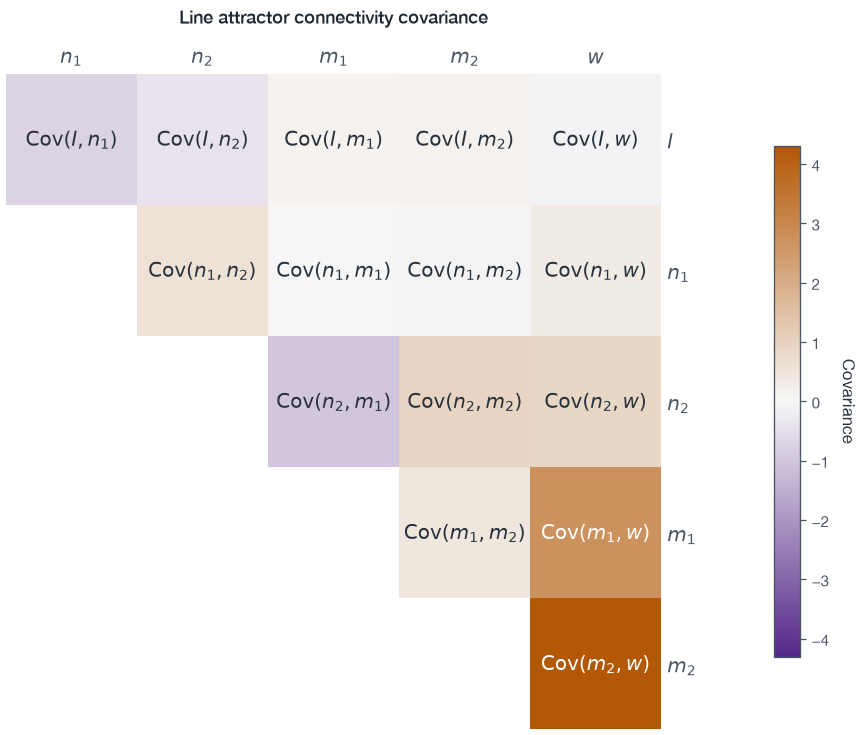

In [19]:
line_attractor = LowRankRNN(NUM_UNITS, rank=RANK)
line_attractor.load_state_dict(torch.load(CHECKPOINT))
line_attractor.eval()

line_vectors = connectivity_vectors(line_attractor)
line_names, line_covariance = connectivity_covariance(line_vectors)
fig, ax = plot_connectivity_covariance(line_names, line_covariance)
ax.set_title("Line attractor connectivity covariance", pad=30)
plt.show()

## 14. Fit a six-dimensional Gaussian to the loading space

The step `model.ipynb` takes for its rank-one network, repeated here. Treat each
neuron's $(I, n_1, n_2, m_1, m_2, w)$ coordinates as one six-dimensional sample
and estimate the joint Gaussian mean and covariance, then draw 128 fresh neurons
from that fit and recompute the section 13 heat map. If the Gaussian is a fair
description of the trained network the two maps should agree up to sampling
noise, and they do - the resampled $n$-$m$ block keeps the same signs and the
same lopsided structure.


In [20]:
loading_names = tuple(line_vectors)
gaussian_mean, gaussian_covariance = fit_loading_gaussian(line_vectors)

print("Loading order:", loading_names)
print("Mean:", np.round(gaussian_mean, 3))
print("Covariance:\n", np.round(gaussian_covariance, 3))

Loading order: ('I', 'n_1', 'n_2', 'm_1', 'm_2', 'w')
Mean: [ 0.036  0.019 -0.225  0.005 -0.162  0.38 ]
Covariance:
 [[ 8.8300e-01 -7.2500e-01 -4.0900e-01  1.0200e-01  1.6500e-01 -9.6000e-02]
 [-7.2500e-01  1.8500e+00  5.6000e-01 -2.0000e-03 -5.6000e-02  3.2700e-01]
 [-4.0900e-01  5.6000e-01  2.0330e+00 -9.9900e-01  9.1000e-01  8.4800e-01]
 [ 1.0200e-01 -2.0000e-03 -9.9900e-01  1.9970e+00  4.5000e-01  2.6940e+00]
 [ 1.6500e-01 -5.6000e-02  9.1000e-01  4.5000e-01  2.3530e+00  4.2750e+00]
 [-9.6000e-02  3.2700e-01  8.4800e-01  2.6940e+00  4.2750e+00  1.6202e+01]]


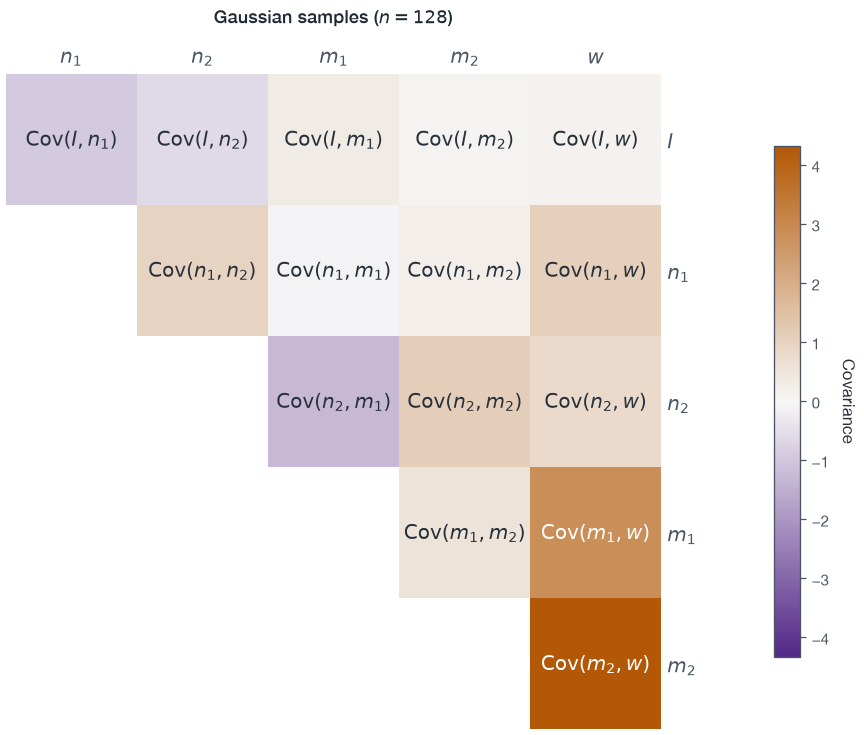

In [21]:
# Match the empirical sample size for a like-for-like covariance comparison.
n_loading_samples = len(line_vectors[loading_names[0]])
gaussian_rng = np.random.default_rng(2026)
sampled_loadings = sample_loading_gaussian(
    gaussian_mean,
    gaussian_covariance,
    num_samples=n_loading_samples,
    rng=gaussian_rng,
)
sampled_vectors = {
    name: sampled_loadings[:, index]
    for index, name in enumerate(loading_names)
}
sampled_names, sampled_covariance = connectivity_covariance(sampled_vectors)

fig, ax = plot_connectivity_covariance(sampled_names, sampled_covariance)
ax.set_title(f"Gaussian samples ($n={n_loading_samples}$)", pad=30)
plt.show()